# The Perceptron Learns the OR Logical Function

In this notebook, we implement—**from scratch and using only NumPy**—the
perceptron algorithm and watch it *learn* the OR logical function.

The central idea: a perceptron draws a **line**, and everything on one side
is class 1, while everything on the other side is class 0. Training = **moving that line** until the examples are
clearly separated.

> We follow the classic algorithm (Marsland):
>
> **Initialization** → small random weights.
> **Training** → for each example: calculate the output and adjust the weights.
> **Recall** → use the learned weights to make predictions.

## Preparation

We import NumPy (computational) and Matplotlib (graphics) and set a clean style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Colors for the two classes (red = 0, green = 1)
C0, C1 = "#E2574C", "#2A9D8F"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8,
    "font.size": 11,
})

## The OR Function

The OR function returns 1 if **at least one** entry is 1:

| $x_1$ | $x_2$ | OR ($t$) |
|:---:|:---:|:---:|
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **1** |

`X` are the inputs and `t` (from *target*) are the correct answers.

In [11]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

t = np.array([0, 1, 1, 1], dtype=float)   # correct answers (OR)

print("Inputs X:\n", X)
print("Targets t:", t)

Inputs X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Targets t: [0. 1. 1. 1.]


## Two Basic Functions

**(a) The bias node.**
To ensure that the line is not forced to pass through the origin, we add a fixed input $x_0 = -1$ to each
example. Thus, the weight $w_0$ acts as a *threshold*.
The sum in the algorithm, $\sum_{i=0}^{m} w_i x_i$, already includes this term.

**(b) The step function $g$.**
It determines the class based on the sign of the sum:

$$g(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$

In [3]:
def add_bias(M):
    """Prepend the bias column x0 = -1 to each row of M."""
    bias_column = -np.ones((M.shape[0], 1))
    return np.hstack([bias_column, M])


def g(z):
    """Step activation: 1 if z > 0, 0 if z <= 0."""
    return np.where(z > 0, 1.0, 0.0)


# Quick Check
print("X with bias:\n", add_bias(X))
print("g(-2, 0, 3) =", g(np.array([-2, 0, 3])))


X with bias:
 [[-1.  0.  0.]
 [-1.  0.  1.]
 [-1.  1.  0.]
 [-1.  1.  1.]]
g(-2, 0, 3) = [0. 0. 1.]


## Training

For each example, we do two things:

1. **Predict:**  $y = g\!\left(\sum_i w_i x_i\right)$
2. **Adjust the weights** using the perceptron rule:

$$w_i \leftarrow w_i - \eta\,(y - t)\,x_i$$

The intuition behind the adjustment:
- If we **get it right** ($y = t$), the term $(y-t)=0$ and the weights **do not change**.
- If we **overpredicted** ($y = 1$, when it should have been $0$), we subtract → the line moves farther away.
- If we **underpredicted** ($y = 0$, when it should have been $1$), we add → the line moves closer.

$\eta$ (*eta*) is the **learning rate**: how large each adjustment is.

We repeat this for several *epochs* (one epoch = one pass through the 4 examples)
**until there are no errors**.

In [4]:
def train_perceptron(X, t, eta=0.2, T=20, seed=80):
    """Train the perceptron and return (final_weights, history).

    history = list of (weights, number_of_errors) at the end of each epoch,
    starting with (initial_weights, None).
    """
    rng = np.random.default_rng(seed)
    Xb = add_bias(X)                 # Add x0 = -1

    # --- Initialization: small random weights (+ and -) ---
    w = rng.uniform(-0.05, 0.05, size=Xb.shape[1])
    history = [(w.copy(), None)]
    print(f"Initial weights: w = {np.round(w, 4)}\n")

    # --- Epoch Loop ---
    for epoch in range(1, T + 1):
        errors = 0
        for i in range(len(Xb)):
            y = g(np.dot(w, Xb[i]))             # 1) predict
            if y != t[i]:
                errors += 1
            w = w - eta * (y - t[i]) * Xb[i]    # 2) correct

        history.append((w.copy(), errors))
        print(f"Epoch {epoch:2d} | errors = {errors} | w = {np.round(w, 4)}")

        if errors == 0:                      # It already separates everything
            print(f"\nConverged at epoch {epoch}!")
            break

    return w, history


Now let's run it. Notice in the output how the number of errors decreases
epoch by epoch until it reaches **0**.

In [5]:
w_final, history = train_perceptron(X, t, eta=0.2, seed=8)


Initial weights: w = [-0.0173  0.0487 -0.0181]

Epoch  1 | errors = 2 | w = [-0.0173  0.0487  0.1819]
Epoch  2 | errors = 2 | w = [-0.0173  0.0487  0.3819]
Epoch  3 | errors = 2 | w = [-0.0173  0.2487  0.3819]
Epoch  4 | errors = 1 | w = [0.1827 0.2487 0.3819]
Epoch  5 | errors = 0 | w = [0.1827 0.2487 0.3819]

Converged at epoch 5!


## Recall: Did the OR really learn anything?

We use the trained weights to predict the 4 cases and compare them with the
truth table.

In [6]:
def recall(X, w):
    """Predict the output of the trained perceptron."""
    return g(add_bias(X) @ w)


print(" x1 x2 | target | prediction")
print(" ------+----------+------------")
for entry, target, prediction in zip(X, t, recall(X, w_final)):
    ok = "OK" if target == prediction else "FAIL"
    print(f"  {int(entry[0])}  {int(entry[1])} |"
          f"    {int(target)}     |"
          f"     {int(prediction)}   {ok}")


 x1 x2 | target | prediction
 ------+----------+------------
  0  0 |    0     |     0   OK
  0  1 |    1     |     1   OK
  1  0 |    1     |     1   OK
  1  1 |    1     |     1   OK


## Visualizing the Decision Boundary

The line separating the classes satisfies $\;-w_0 + w_1 x_1 + w_2 x_2 = 0\;$
(remember that $x_0=-1$). Solving for $x_2$:

$$x_2 = \frac{w_0 - w_1\,x_1}{w_2}$$

This function plots that line, shades the two regions, and places the 4 points.

In [7]:
def draw_boundary(ax, w, title):
    """Draw the regions, the boundary line, and the four points of OR on the x-axis."""
    # Regions: We evaluate the perceptron on a grid of points
    rx = np.linspace(-0.4, 1.4, 250)
    xx, yy = np.meshgrid(rx, rx)
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = recall(grid, w).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5],
                colors=[C0, C1], alpha=0.16)

    # Straight Border
    w0, w1, w2 = w
    if abs(w2) > 1e-9:
        ax.plot(rx, (w0 - w1 * rx) / w2, color="#1D3557", lw=2.2)
    elif abs(w1) > 1e-9:
        ax.axvline(w0 / w1, color="#1D3557", lw=2.2)

    # The 4 points (colored by class)
    for entry, target in zip(X, t):
        color = C1 if target == 1 else C0
        ax.scatter(*entry, s=190, color=color, zorder=5,
                   edgecolors="white", linewidths=1.6)
        ax.annotate(f"{int(target)}", entry, color="white",
                    ha="center", va="center", fontweight="bold", zorder=6)

    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(title, fontweight="bold")
    ax.set_aspect("equal")


### Figure 1. The boundary shifting from epoch to epoch

Each panel shows the state after one epoch. You will see the line slope downward until the
point $(0,0)$ is left alone in the red region.

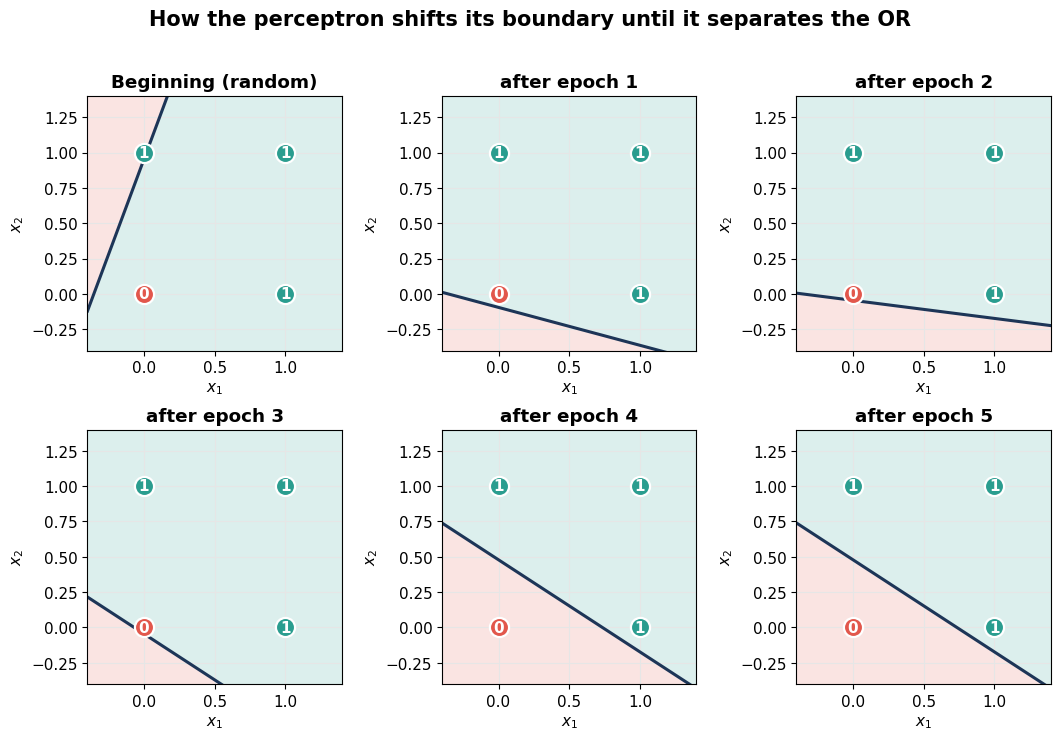

In [8]:
panels = [(i, w) for i, (w, _) in enumerate(history)]
n = len(panels)
cols = 3 if n in (5, 6) else min(n, 4)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.6 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes[n:]:
    ax.axis("off")
for ax, (i, w) in zip(axes, panels):
    label = "Beginning (random)" if i == 0 else f"after epoch {i}"
    draw_boundary(ax, w, label)

fig.suptitle("How the perceptron shifts its boundary until it separates the OR",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


### Figure 2. Training Summary

(a) Errors over time · (b) How the weights change · (c) Final boundary.

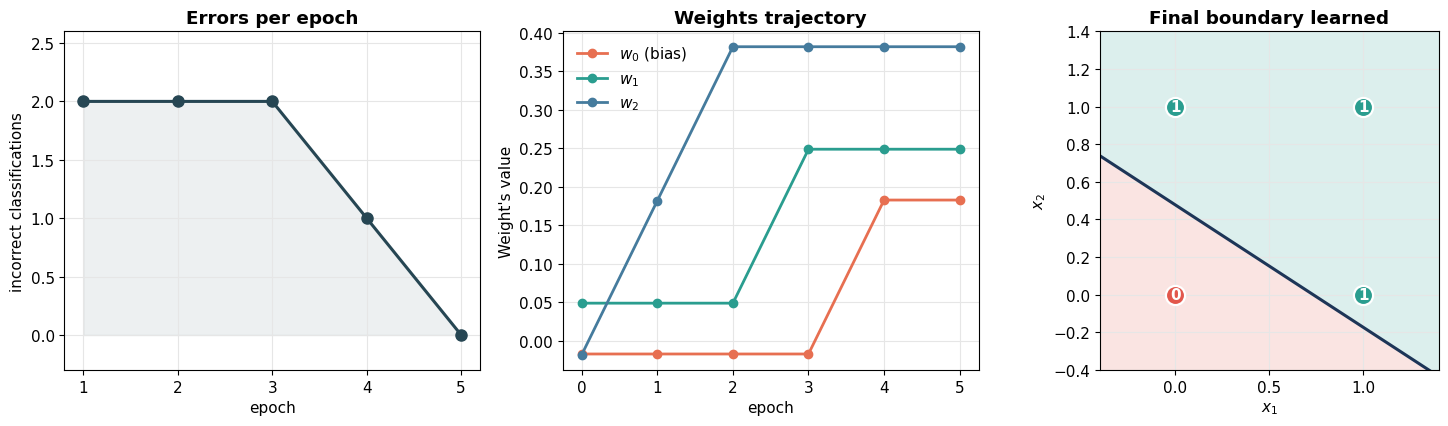

In [9]:
errors_list = [e for (_, e) in history[1:]]
epochs = np.arange(1, len(errors_list) + 1)
W = np.array([w for (w, _) in history])

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) Errors per epoch
a1.plot(epochs, errors_list, "-o", color="#264653", lw=2.2, ms=8)
a1.fill_between(epochs, errors_list, color="#264653", alpha=0.08)
a1.set_title("Errors per epoch", fontweight="bold")
a1.set_xlabel("epoch"); a1.set_ylabel("incorrect classifications")
a1.set_xticks(epochs); a1.set_ylim(-0.3, max(errors_list) + 0.6)

# (b) Trajectory of the weights
names = ["$w_0$ (bias)", "$w_1$", "$w_2$"]
colors = ["#E76F51", "#2A9D8F", "#457B9D"]
for k in range(W.shape[1]):
    a2.plot(range(len(W)), W[:, k], "-o", lw=2, ms=6,
            color=colors[k], label=names[k])
a2.set_title("Weights trajectory", fontweight="bold")
a2.set_xlabel("epoch"); a2.set_ylabel("Weight's value")
a2.set_xticks(range(len(W))); a2.legend(frameon=False)

# (c) Final boundary
draw_boundary(a3, w_final, "Final boundary learned")

fig.tight_layout()
plt.show()


> **Do you want to save the plots as images?**
> Add `fig.savefig(“or_evolucion.png”, dpi=150, bbox_inches="tight")`
> *before* `plt.show()`. It will be saved in the folder where this notebook is located.

## Classroom Experiments

Ideas for you to explore (just change one line):

1. **Learning rate:** Try `eta=0.05` and `eta=1.0`. Does the number of epochs change?
2. **Different seed:** `seed=3`, `seed=20`… the line starts from a different point.
3. **AND function:** change the targets to `t = [0, 0, 0, 1]`. It also converges (it is separable).
4. **XOR function:** use `t = [0, 1, 1, 0]`. **It never reaches 0 errors**: a single
   perceptron cannot separate the XOR with a straight line. This is the historic example that
   led to the development of multilayer networks.

The following cell tests the XOR so you can see that the errors **do not** drop to 0.

In [10]:
t_xor = np.array([0, 1, 1, 0], dtype=float)   # XOR
print("Attempting to learn XOR with a single perceptron:\n")
_, history_xor = train_perceptron(X, t_xor, eta=0.2, T=12, seed=8)
print("\nErrors keep oscillating: XOR is NOT linearly separable.")


Attempting to learn XOR with a single perceptron:

Initial weights: w = [-0.0173  0.0487 -0.0181]

Epoch  1 | errors = 3 | w = [ 0.1827 -0.1513 -0.0181]
Epoch  2 | errors = 3 | w = [-0.0173 -0.1513 -0.0181]
Epoch  3 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  4 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  5 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  6 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  7 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  8 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch  9 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch 10 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch 11 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]
Epoch 12 | errors = 4 | w = [-0.0173 -0.1513 -0.0181]

Errors keep oscillating: XOR is NOT linearly separable.
